In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from github_helper import from_github
from overseas_parties import overseas_parties

In [2]:
edge_df = pd.read_csv(from_github("/edges/party/all_party_edges_by_Period.csv"))
edge_df = edge_df[edge_df['Period']!=65] #We drop Period 65, as it does not seem to be representative. This is already done in the dataframe building, but needs to be propogated up to here.

## Biggest Network Changes
In the following, we find out which topics and periods are most interesting to investigate. We remove small parties, and compute the absolute differences in agreement over time and periods.

In [3]:
overseas_parties_mask = (edge_df['source'].isin(overseas_parties) | edge_df['target'].isin(overseas_parties)) #Remove overseas parties as they have incredibly few representatives, so their "Agreement" is extremely volatile, which affects the calculations too much.
la_66_mask = (((edge_df['source'] == "Liberal Alliance") | (edge_df['target'] == "Liberal Alliance")) & (edge_df['Period'] == 66)) #Also remove LA in 66, as they just started at the very end of their period.
edge_traditional = edge_df[(~overseas_parties_mask) & (~la_66_mask)]

#Remove self-relations
self_edges = (edge_traditional['source'] == edge_traditional['target'])
edge_traditional = edge_traditional[~self_edges]

In [4]:
periods = [66, 67, 68, 69, 70, 71] # 65
wide = (edge_traditional.pivot_table(
        index=['source', 'target', 'topic'],
        columns='Period',
        values='weight').reindex(columns=periods)).reset_index()


def average_pair_differences(
    wide: pd.DataFrame,
    periods=periods,
    topic=None,            # e.g., "general" or ["general","skat"]; None = all topics
    ax = None
):
    """
    Compute the average absolute difference for each (period_a, period_b) pair,
    optionally filtered by topic, and plot a descending bar chart.

    Parameters
    ----------
    wide : DataFrame
        Must contain columns ['source','target','topic', <period columns>].
    periods : list[int]
        Period columns to use.
    topic : str | list[str] | None
        Optional topic filter. If provided, only rows with these topics are used.

    Returns
    -------
    df_pairs : pd.DataFrame
        DataFrame indexed by (p1, p2) with columns:
          - mean_diff : mean absolute difference across rows (ignoring NaNs per row)
          - n_valid   : number of rows with both periods non-NaN for this pair
          - std_diff  : std of absolute differences across valid rows (NaNs ignored)
    ax : matplotlib.axes.Axes
        The axis of the bar plot.
    """

    # --- Filter by topic if requested ---
    if topic is not None:
        if isinstance(topic, (list, tuple, set)):
            wide_use = wide[wide['topic'].isin(topic)].copy()
        else:
            wide_use = wide[wide['topic'] == topic].copy()
    else:
        wide_use = wide[wide['topic'] != "general"].copy()

    if wide_use.empty:
        raise ValueError("No rows after topic filter. Check your 'topic' value(s).")

    # --- Validate period columns ---
    period_cols = [c for c in periods if c in wide_use.columns]
    if not period_cols:
        raise ValueError("No matching period columns found in 'wide'.")

    # --- Build pairwise diffs ---
    combs = list(combinations(period_cols, 2))
    out_rows = []
    for a, b in combs:
        diff = (wide_use[a] - wide_use[b]).abs()
        invalid = wide_use[[a, b]].isna().any(axis=1)
        diff[invalid] = np.nan

        vals = diff.to_numpy()
        n_valid = np.sum(~np.isnan(vals))
        mean_diff = float(np.nanmean(vals)) if n_valid > 0 else np.nan
        std_diff  = float(np.nanstd(vals))  if n_valid > 1 else np.nan

        out_rows.append((a, b, mean_diff, n_valid, std_diff))

    df_pairs = pd.DataFrame(out_rows, columns=["p1", "p2", "mean_diff", "n_valid", "std_diff"])
    df_pairs = df_pairs.set_index(["p1", "p2"]).sort_values("mean_diff", ascending=False)

    # --- Plot ---
    cmap = plt.cm.viridis
    mid_color = cmap(0.5)  # midpoint color

    labels = [f"{a}–{b}" for a, b in df_pairs.index]
    vals = df_pairs["mean_diff"].values

    # fig, ax = plt.subplots(figsize=(20, 10))
    ax.bar(labels, vals, color=mid_color, alpha=0.8)
    ax.set_ylabel("Average Absolute Difference in Agreement")
    title_suffix = f" (topic: {topic})" if topic is not None else " (all topics)"
    ax.set_title(f"Average Difference by period combination{title_suffix}")
    ax.tick_params(axis="x", rotation=45)

    # Annotate counts (n_valid) above bars
    for i, v in enumerate(vals):
        n = df_pairs["n_valid"].iloc[i]
        ax.text(i, v, f"n={n}", ha="center", va="bottom", fontsize=8)

    # plt.tight_layout()

    return ax

def plot_topic_change_boxplot(
    wide: pd.DataFrame,
    period_start=66,
    period_end=71,
    ax = None
):
    """
    Compute absolute differences between period_start and period_end for each topic,
    then plot a boxplot across all topics, sorted by the average absolute difference.
    Custom lines mark the mean (solid) and median (dashed), with legend entries.
    Returns the Matplotlib axis (ax) for further customization.
    """

    # --- Sanity check ---
    if period_start not in wide.columns or period_end not in wide.columns:
        raise ValueError(f"Missing columns {period_start} or {period_end} in DataFrame")

    # --- Compute absolute change ---
    wide = wide.copy()
    wide["abs_change"] = (wide[period_end] - wide[period_start]).abs()
    wide_valid = wide.dropna(subset=["abs_change"])

    # --- Group by topic ---
    topic_groups = wide_valid.groupby("topic")["abs_change"].apply(list)
    topic_means = topic_groups.apply(np.nanmean)
    topic_medians = topic_groups.apply(np.nanmedian)

    # --- Sort topics by mean absolute change ---
    topic_order = topic_means.sort_values(ascending=False).index
    data_to_plot = [topic_groups[t] for t in topic_order]
    mean_values = [topic_means[t] for t in topic_order]
    median_values = [topic_medians[t] for t in topic_order]

    # --- Plot ---
    # fig, ax = plt.subplots(figsize=(12, 6))

    # Get mid viridis color
    cmap = plt.cm.viridis
    mid_color = cmap(0.5)

    # Create boxplot with median lines hidden
    bp = ax.boxplot(
        data_to_plot,
        tick_labels=topic_order,
        patch_artist=True,
        medianprops=dict(color='none'),  # hide built-in median lines
    )

    # Apply consistent color + transparency
    for patch in bp['boxes']:
        patch.set_facecolor(mid_color)
        patch.set_alpha(0.7)

    # --- Add custom mean and median lines ---
    for i, (mean_val, median_val) in enumerate(zip(mean_values, median_values), start=1):
        # Mean line
        ax.plot([i - 0.3, i + 0.3], [mean_val, mean_val],
                color=cmap(1.0), lw=2.0, label='_nolegend_')
        # Median line
        ax.plot([i - 0.3, i + 0.3], [median_val, median_val],
                color=cmap(0.9), lw=1.8, linestyle='--', label='_nolegend_')

    # --- Legend ---
    ax.plot([], [], color=cmap(1.0), lw=2.0, label='Mean Absolute Difference')
    ax.plot([], [], color=cmap(0.9), lw=1.8, linestyle='--', label='Median Absolute Difference')
    ax.legend(loc='upper right')

    # --- Formatting ---
    ax.set_title(
        f"Absolute Difference from period {period_start} to {period_end} by topic"
    )
    ax.set_ylabel("Absolute Difference in Agreement")
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    return ax

def plot_party_change_boxplot(
    wide: pd.DataFrame,
    topic="immigration",
    period_start=66,
    period_end=71,
    ax=None
):
    """
    For a given topic, compute absolute differences between two periods for all party pairs.
    Each party (appearing as source or target) gets a boxplot showing its distribution of
    absolute differences across all edges it is involved in.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis containing the plot.
    """

    # --- Sanity checks ---
    if "topic" not in wide.columns:
        raise ValueError("The DataFrame must contain a 'topic' column.")
    if period_start not in wide.columns or period_end not in wide.columns:
        raise ValueError(f"Missing columns {period_start} or {period_end} in DataFrame")

    # --- Filter by topic ---
    df_topic = wide[wide["topic"] == topic].copy()
    if df_topic.empty:
        raise ValueError(f"No rows found for topic '{topic}'.")

    # --- Compute absolute change ---
    df_topic["abs_change"] = (df_topic[period_end] - df_topic[period_start]).abs()
    df_topic = df_topic.dropna(subset=["abs_change"])

    # --- Collect per-party absolute changes (source or target) ---
    parties = pd.unique(df_topic[["source", "target"]].values.ravel("K"))
    party_groups = {}
    for party in parties:
        mask = (df_topic["source"] == party) | (df_topic["target"] == party)
        party_groups[party] = df_topic.loc[mask, "abs_change"].tolist()

    # --- Compute mean and median per party ---
    party_means = {p: np.nanmean(v) for p, v in party_groups.items()}
    party_medians = {p: np.nanmedian(v) for p, v in party_groups.items()}

    # --- Sort parties by mean difference ---
    party_order = sorted(party_means.keys(), key=lambda p: party_means[p], reverse=True)

    data_to_plot = [party_groups[p] for p in party_order]
    mean_values = [party_means[p] for p in party_order]
    median_values = [party_medians[p] for p in party_order]

    # --- Set up plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    cmap = plt.cm.viridis
    mid_color = cmap(0.5)

    bp = ax.boxplot(
        data_to_plot,
        tick_labels=party_order,
        patch_artist=True,
        medianprops=dict(color="none")  # hide default medians
    )

    # --- Style boxes ---
    for patch in bp["boxes"]:
        patch.set_facecolor(mid_color)
        patch.set_alpha(0.7)

    # --- Add custom mean and median lines ---
    for i, (mean_val, median_val) in enumerate(zip(mean_values, median_values), start=1):
        # Mean
        ax.plot([i - 0.3, i + 0.3], [mean_val, mean_val],
                color=cmap(1.0), lw=2.0, label='_nolegend_')
        # Median
        ax.plot([i - 0.3, i + 0.3], [median_val, median_val],
                color=cmap(0.9), lw=1.8, linestyle='--', label='_nolegend_')

    # --- Legend ---
    ax.plot([], [], color=cmap(1.0), lw=2.0, label="Mean Absolute Difference")
    ax.plot([], [], color=cmap(0.9), lw=1.8, linestyle="--", label="Median Absolute Difference")
    ax.legend(loc="upper right")

    # --- Formatting ---
    ax.set_title(
        f"Absolute Difference by Party for '{topic}', Period 66 to 71"
    )
    ax.set_ylabel("Absolute Difference in Agreement")
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    return ax


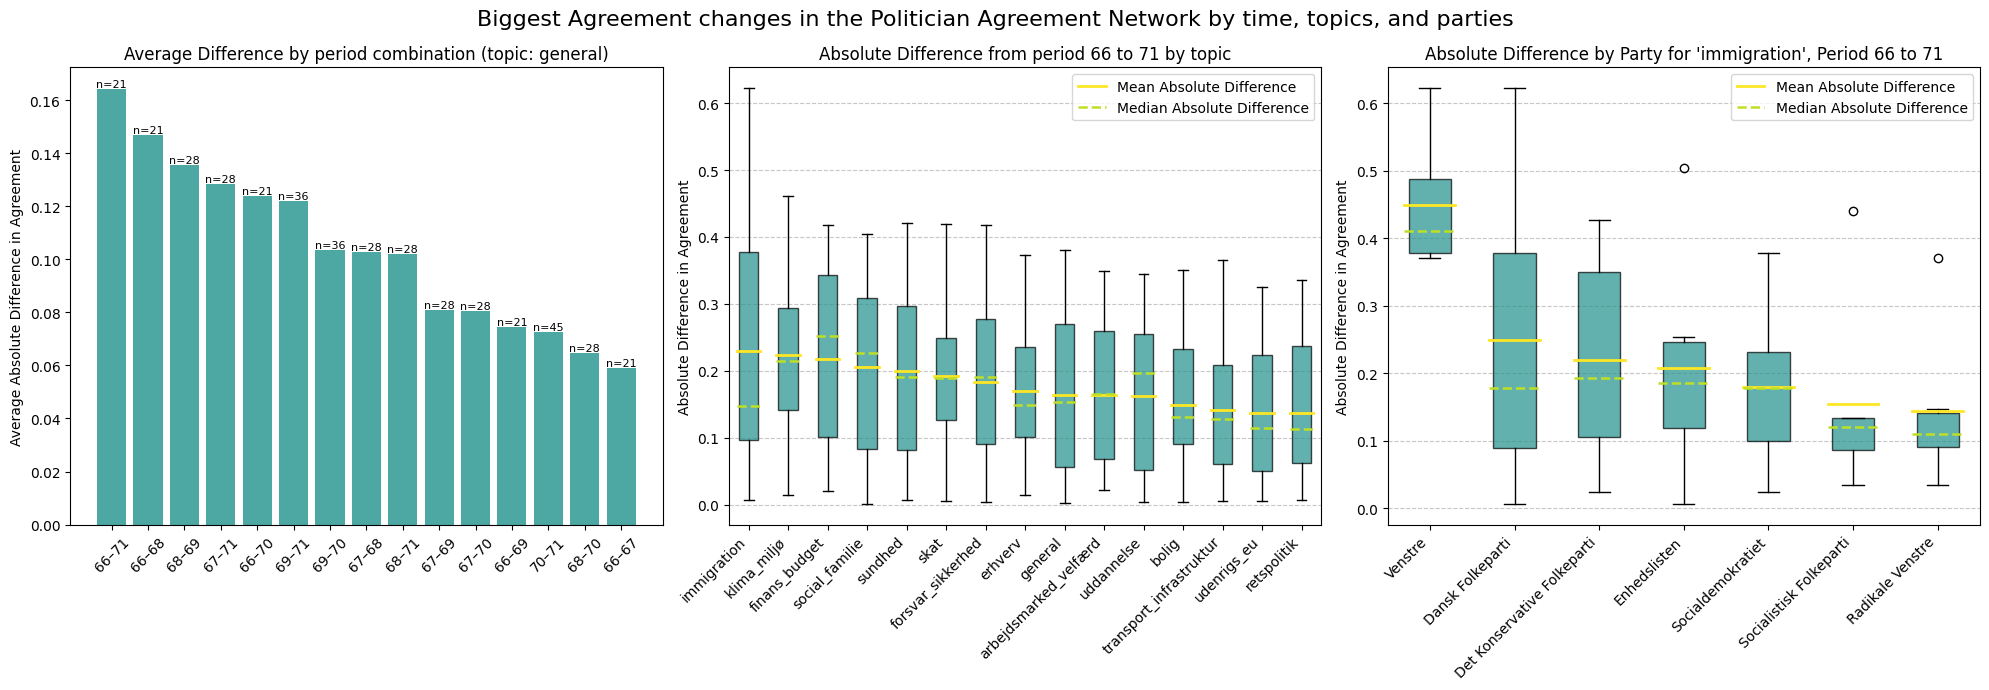

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

average_pair_differences(wide, ax = axs[0], topic = "general")
plot_topic_change_boxplot(wide, ax = axs[1])
plot_party_change_boxplot(wide, ax = axs[2])

plt.suptitle("Biggest Agreement changes in the Politician Agreement Network by time, topics, and parties", fontsize = 16)
plt.tight_layout()
plt.show()

The biggest average absolute difference is between period 66 and 71. It seems trivial as they are the furthest apart in time but the second largest difference is betweeen 66 and 68, so it is not so straightforward.  
We therefore investigate which topics drive the difference from period 66 to 71.  
While the Median absolute difference is highest for finans_budget, the mean absolute is highest for immigration, and immigration has, by far, the biggest variance in absolute difference, as is seen from the upper quantiles.  
From our analysis going forward, we therefore mainly investigate the changes from period 66 to period 71, for the immigration topic.  
In the immigration topic, Venstre has the largest 